In [1]:
from pathlib import Path
import shutil
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPPy.utilities.metrics import PSNR, SSIM
from IPPy.nn.models import UNet

from utils.data_utils import load_normalized_image

# ============================================================
# CONFIGURAZIONE -- percorsi locali (dataset gia' presente in locale)
# ============================================================

TEST_DIR = Path("../dataset_resized/test_resized")        # ground truth: root/paziente/slice.png
FBP_DIR = Path("../fbp") / "test"                          # input FBP:    root/n_angoli/paziente/slice.npy
TV_DIR = Path("../tv_reconstructions") / "test"            # ricostruzioni TV (target di training UNet)

# Aggiorna questo percorso se in locale i pesi allenati stanno altrove
UNET_WEIGHTS_DIR = Path("../modelli_unet")                 # root/n_angoli/model_weights.pth
UNET_RECON_DIR = Path("../unet_reconstructions") / "test"  # output di QUESTO script

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_ANGLES_CONFIGS = [90, 45, 30, 15]

ANGLE_INTERVALS = {
    90: "[-45°, 45°]",
    45: "[-45°, 45°]",
    30: "(-30°, 30°)",
    15: "(-30°, 30°)",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ------------------------------------------------------------
# Ricrea la cartella di output ad ogni run: nessuna ricostruzione
# "vecchia" resta in giro se cambi modello, pesi o configurazione.
# ------------------------------------------------------------
if UNET_RECON_DIR.exists():
    shutil.rmtree(UNET_RECON_DIR)
UNET_RECON_DIR.mkdir(parents=True)
print(f"Cartella di output ricreata: {UNET_RECON_DIR}")

Device: cpu
Cartella di output ricreata: ..\unet_reconstructions\test


In [3]:
# ============================================================
# Caricamento dei 4 modelli UNet allenati (uno per configurazione angolare)
# ============================================================

def infer_unet_config(state_dict):
    """Ricava i parametri costruttivi di IPPy.nn.models.UNet dalle shape
    del checkpoint. NOTA: 'final_activation' non ha pesi propri (e' solo
    la sigmoide applicata dopo l'ultimo layer) quindi non e' deducibile
    dallo state_dict e va impostata qui a mano, coerente con MODEL_CONFIG
    usata in 04_unet.ipynb in fase di training (altrimenti i pesi si
    caricano comunque SENZA ERRORI -- bug silenzioso -- ma l'output non
    e' piu' vincolato in [0,1] come si aspetta il resto della pipeline).
    """
    ch_in = state_dict["preprocess.conv.0.weight"].shape[1]
    middle_ch = [state_dict["preprocess.conv.0.weight"].shape[0]]

    i = 0
    while f"encoder_layers.{i}.conv.conv2.weight" in state_dict:
        middle_ch.append(state_dict[f"encoder_layers.{i}.conv.conv2.weight"].shape[0])
        i += 1
    n_blocks = i

    ch_out = state_dict["postprocess.weight"].shape[0]

    return {
        "ch_in": ch_in,
        "ch_out": ch_out,
        "middle_ch": middle_ch,
        "n_layers_per_block": 2,
        "down_layers": tuple(["ResDownBlock"] * n_blocks),
        "up_layers": tuple(["ResUpBlock"] * n_blocks),
        "final_activation": "sigmoid",  # FIX: coerente con MODEL_CONFIG del training
    }


def load_unet_model(n_angles: int) -> torch.nn.Module:
    weights_path = UNET_WEIGHTS_DIR / str(n_angles) / "model_weights.pth"
    state_dict = torch.load(weights_path, map_location=DEVICE)

    config = infer_unet_config(state_dict)
    print(f"{n_angles} angoli -> {config}")

    model = UNet(**config)
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model


models = {n_angles: load_unet_model(n_angles) for n_angles in N_ANGLES_CONFIGS}

90 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
45 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
30 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
15 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}


In [4]:
# ------------------------------------------------------------
# Inferenza UNet su TUTTO il test set, per ciascuna configurazione
# angolare. Le predizioni vengono salvate su disco: verranno RILETTE
# (non ricalcolate) sia per il confronto con TV qui sotto, sia per
# quello con la ground truth nella sezione 2.
# ------------------------------------------------------------

for n_angles in N_ANGLES_CONFIGS:
    model = models[n_angles]

    input_paths = sorted(
        (FBP_DIR / str(n_angles)).rglob("*.npy"),
        key=lambda p: (p.parent.name, int(p.stem))
    )

    for input_path in tqdm(input_paths, desc=f"Inferenza UNet [{n_angles} angoli]"):
        rel_path = input_path.relative_to(FBP_DIR / str(n_angles))  # paziente/slice.npy
        out_path = UNET_RECON_DIR / str(n_angles) / rel_path
        out_path.parent.mkdir(parents=True, exist_ok=True)

        x_input = np.clip(np.load(input_path).astype(np.float32), 0.0, 1.0)
        x_input = torch.from_numpy(x_input).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            x_output = model(x_input)

        np.save(out_path, x_output.squeeze().cpu().numpy())

print("Predizioni generate e salvate su disco per tutte le configurazioni.")

Inferenza UNet [15 angoli]: 100%|██████████| 327/327 [08:37<00:00,  1.58s/it]

Predizioni generate e salvate su disco per tutte le configurazioni.


In [8]:
# ------------------------------------------------------------
# Funzioni riusate nei confronti (qui e nella sezione 2)
# ------------------------------------------------------------

def load_npy_clipped(path: Path) -> np.ndarray:
    return np.clip(np.load(path).astype(np.float32), 0.0, 1.0)


def tv_path_from_unet(pred_path: Path, n_angles: int) -> Path:
    rel = pred_path.relative_to(UNET_RECON_DIR / str(n_angles))
    return TV_DIR / str(n_angles) / rel


def gt_path_from_unet(pred_path: Path, n_angles: int) -> Path:
    rel = pred_path.relative_to(UNET_RECON_DIR / str(n_angles))
    return (TEST_DIR / rel).with_suffix(".png")


def evaluate_reconstructions(pred_root: Path, ref_path_fn, ref_loader_fn, n_angles_configs, desc: str):
    """Calcola PSNR/SSIM confrontando, una per una, le ricostruzioni sotto
    pred_root/<n_angoli>/... con una reference ottenuta da
    ref_path_fn(percorso_predizione, n_angoli)."""
    results = {}
    for n_angles in n_angles_configs:
        pred_paths = sorted((pred_root / str(n_angles)).rglob("*.npy"))
        psnr_values, ssim_values = [], []

        for pred_path in tqdm(pred_paths, desc=f"{desc} [{n_angles} angoli]"):
            ref_path = ref_path_fn(pred_path, n_angles)
            if ref_path is None or not ref_path.exists():
                continue

            ref = ref_loader_fn(ref_path)
            pred = load_npy_clipped(pred_path)
            if ref.shape != pred.shape:
                print(f"Shape diverse per {pred_path}: ref={ref.shape}, pred={pred.shape}")
                continue

            x_ref = torch.from_numpy(ref).float().unsqueeze(0).unsqueeze(0)
            x_pred = torch.from_numpy(pred).float().unsqueeze(0).unsqueeze(0)
            psnr_values.append(float(PSNR(x_pred, x_ref)))
            ssim_values.append(float(SSIM(x_pred, x_ref)))

        results[n_angles] = {"PSNR": psnr_values, "SSIM": ssim_values}
    return results


def print_summary(results, title):
    print(f"\n{'='*20} {title} {'='*20}")
    for n_angles in N_ANGLES_CONFIGS:
        psnr_values = np.array(results[n_angles]["PSNR"])
        ssim_values = np.array(results[n_angles]["SSIM"])
        print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
        print(f"Numero slice: {len(psnr_values)}")
        print(f"PSNR medio: {psnr_values.mean():.2f} ± {psnr_values.std():.2f} dB")
        print(f"SSIM medio: {ssim_values.mean():.4f} ± {ssim_values.std():.4f}")

In [9]:
# ------------------------------------------------------------
# Metriche UNet vs TV: confronto predizione-per-predizione su TUTTO
# il test set (tutti gli angoli, tutti i pazienti/slice)
# ------------------------------------------------------------

results_unet_vs_tv = evaluate_reconstructions(
    UNET_RECON_DIR, tv_path_from_unet, load_npy_clipped, N_ANGLES_CONFIGS, "UNet vs TV"
)
print_summary(results_unet_vs_tv, "UNET vs TV -- test set completo")

UNet vs TV [15 angoli]: 100%|██████████| 327/327 [00:05<00:00, 59.15it/s]


==================== UNET vs TV -- test set completo ====================

90 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 30.64 ± 0.63 dB
SSIM medio: 0.8994 ± 0.0140

45 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 30.66 ± 0.97 dB
SSIM medio: 0.9000 ± 0.0108

30 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 28.66 ± 1.36 dB
SSIM medio: 0.8859 ± 0.0169

15 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 29.06 ± 1.45 dB
SSIM medio: 0.8815 ± 0.0179


Slice scelta a caso: C081\121.npy (mostrata su tutti gli angoli)


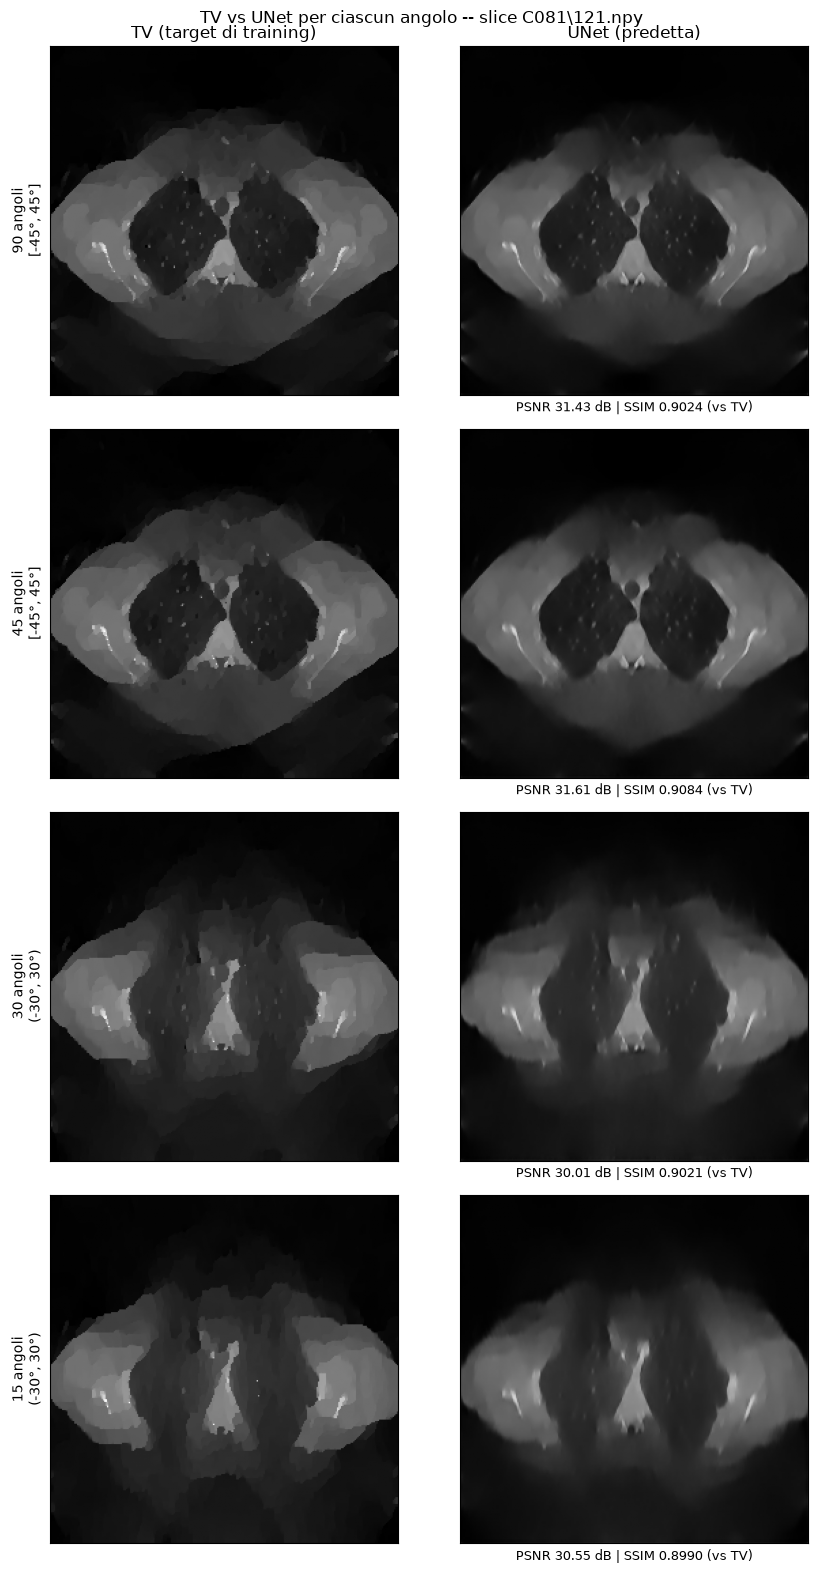

In [11]:
# ------------------------------------------------------------
# Confronto visivo: la STESSA slice dello STESSO paziente, mostrata
# su tutti e 4 gli angoli -- una foto predetta per angolo, ciascuna
# confrontata con la sua ricostruzione TV corrispondente.
# ------------------------------------------------------------

random.seed(123)  # riproducibile, stesso seed usato in 01_preprocessing.ipynb

# La slice viene scelta guardando la config a 90 angoli come riferimento
# (stessa struttura paziente/slice per tutte le configurazioni angolari)
reference_paths = sorted((UNET_RECON_DIR / "90").rglob("*.npy"))
demo_rel_path = random.choice(reference_paths).relative_to(UNET_RECON_DIR / "90")
print(f"Slice scelta a caso: {demo_rel_path} (mostrata su tutti gli angoli)")

fig, axs = plt.subplots(len(N_ANGLES_CONFIGS), 2, figsize=(9, 4 * len(N_ANGLES_CONFIGS)))

for row, n_angles in enumerate(N_ANGLES_CONFIGS):
    pred = load_npy_clipped(UNET_RECON_DIR / str(n_angles) / demo_rel_path)
    tv = load_npy_clipped(TV_DIR / str(n_angles) / demo_rel_path)

    pred_t = torch.from_numpy(pred).float().unsqueeze(0).unsqueeze(0)
    tv_t = torch.from_numpy(tv).float().unsqueeze(0).unsqueeze(0)
    psnr_val = float(PSNR(pred_t, tv_t))
    ssim_val = float(SSIM(pred_t, tv_t))

    axs[row, 0].imshow(tv, cmap="gray", vmin=0, vmax=1)
    axs[row, 0].set_ylabel(f"{n_angles} angoli\n{ANGLE_INTERVALS[n_angles]}", fontsize=10)
    if row == 0:
        axs[row, 0].set_title("TV (target di training)")
    axs[row, 0].set_xticks([]); axs[row, 0].set_yticks([])

    axs[row, 1].imshow(pred, cmap="gray", vmin=0, vmax=1)
    if row == 0:
        axs[row, 1].set_title("UNet (predetta)")
    axs[row, 1].set_xlabel(f"PSNR {psnr_val:.2f} dB | SSIM {ssim_val:.4f} (vs TV)", fontsize=9)
    axs[row, 1].set_xticks([]); axs[row, 1].set_yticks([])

plt.suptitle(f"TV vs UNet per ciascun angolo -- slice {demo_rel_path}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "demo_tv_vs_unet.png", dpi=150)
plt.show()

Slice scelta a caso per il confronto con la ground truth: C081\221.npy


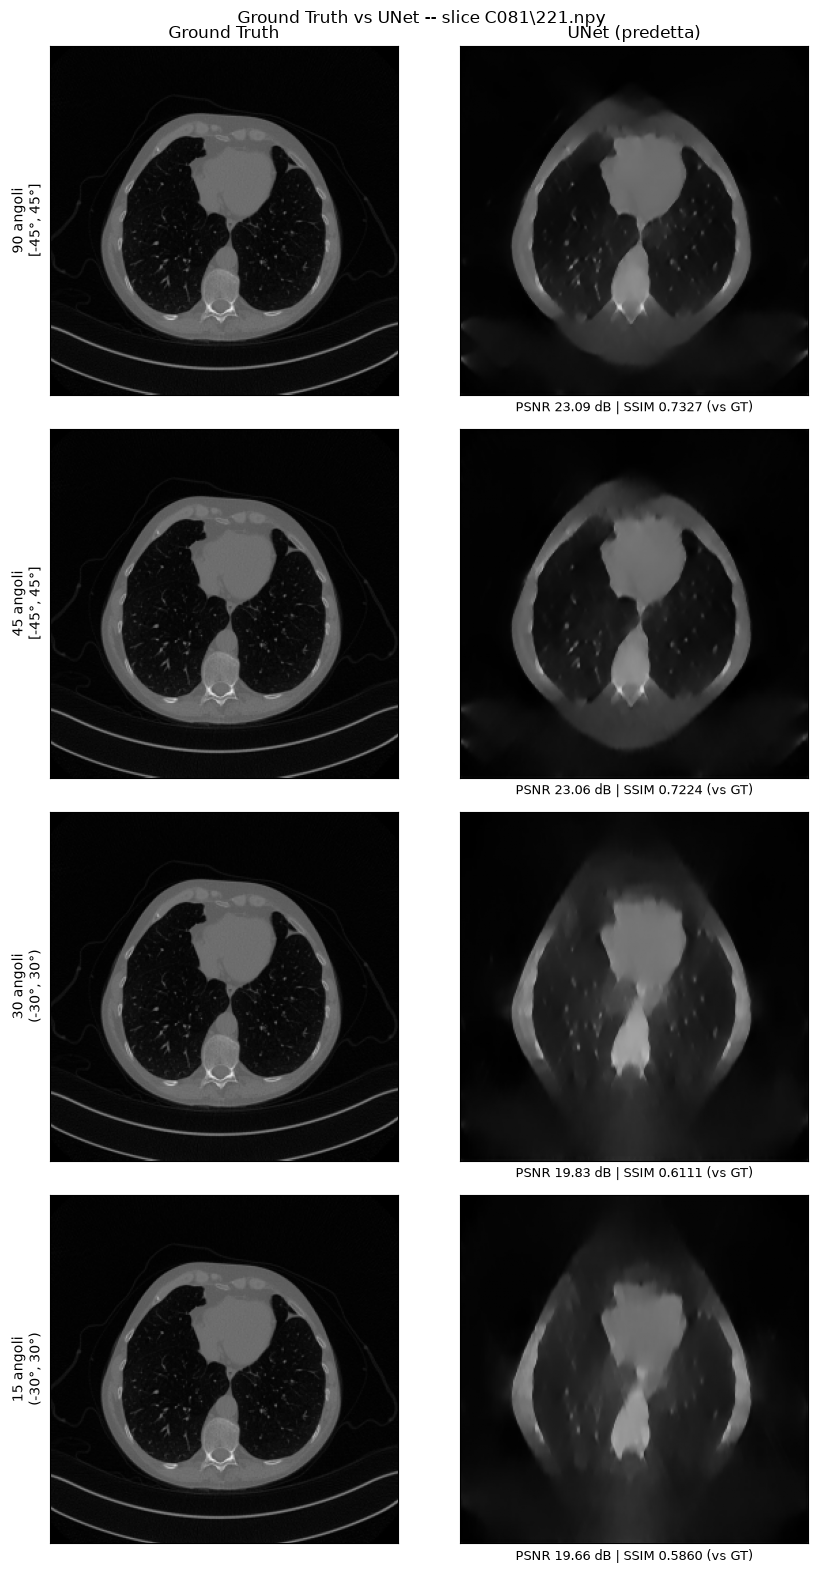

In [12]:
# ------------------------------------------------------------
# Confronto visivo: stessa slice mostrata su tutti e 4 gli angoli,
# Ground Truth vs UNet (UNet riletta dal disco, non ricalcolata)
# ------------------------------------------------------------

reference_paths = sorted((UNET_RECON_DIR / "90").rglob("*.npy"))
demo_rel_path_gt = random.choice(reference_paths).relative_to(UNET_RECON_DIR / "90")
print(f"Slice scelta a caso per il confronto con la ground truth: {demo_rel_path_gt}")

gt_path = (TEST_DIR / demo_rel_path_gt).with_suffix(".png")
gt = load_normalized_image(gt_path)
gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

fig, axs = plt.subplots(len(N_ANGLES_CONFIGS), 2, figsize=(9, 4 * len(N_ANGLES_CONFIGS)))

for row, n_angles in enumerate(N_ANGLES_CONFIGS):
    unet = load_npy_clipped(UNET_RECON_DIR / str(n_angles) / demo_rel_path_gt)  # letta dal disco
    unet_t = torch.from_numpy(unet).float().unsqueeze(0).unsqueeze(0)
    psnr_val = float(PSNR(unet_t, gt_t))
    ssim_val = float(SSIM(unet_t, gt_t))

    axs[row, 0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axs[row, 0].set_ylabel(f"{n_angles} angoli\n{ANGLE_INTERVALS[n_angles]}", fontsize=10)
    if row == 0:
        axs[row, 0].set_title("Ground Truth")
    axs[row, 0].set_xticks([]); axs[row, 0].set_yticks([])

    axs[row, 1].imshow(unet, cmap="gray", vmin=0, vmax=1)
    if row == 0:
        axs[row, 1].set_title("UNet (predetta)")
    axs[row, 1].set_xlabel(f"PSNR {psnr_val:.2f} dB | SSIM {ssim_val:.4f} (vs GT)", fontsize=9)
    axs[row, 1].set_xticks([]); axs[row, 1].set_yticks([])

plt.suptitle(f"Ground Truth vs UNet -- slice {demo_rel_path_gt}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "demo_unet_vs_gt.png", dpi=150)
plt.show()

In [13]:
# ------------------------------------------------------------
# Metriche UNet vs Ground Truth: confronto predizione-per-predizione
# su TUTTO il test set -- metrica di qualita' finale.
# ------------------------------------------------------------

results_unet_vs_gt = evaluate_reconstructions(
    UNET_RECON_DIR, gt_path_from_unet, load_normalized_image, N_ANGLES_CONFIGS, "UNet vs GT"
)
print_summary(results_unet_vs_gt, "UNET vs GROUND TRUTH -- test set completo (metrica finale)")

UNet vs GT [15 angoli]: 100%|██████████| 327/327 [00:08<00:00, 37.63it/s]


==================== UNET vs GROUND TRUTH -- test set completo (metrica finale) ====================

90 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 23.35 ± 1.64 dB
SSIM medio: 0.7189 ± 0.0385

45 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 23.32 ± 1.48 dB
SSIM medio: 0.7153 ± 0.0376

30 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 21.15 ± 1.98 dB
SSIM medio: 0.6250 ± 0.0579

15 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 20.91 ± 2.12 dB
SSIM medio: 0.6139 ± 0.0493
